<a href="https://colab.research.google.com/github/pramod12r/SER-Wristband/blob/main/anrf_pilot_ser_noise_wesad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARG pilot run: noise robustness of speech emotion recognition + wristband stress baseline

**Part A** measures how much outdoor noise degrades speech emotion recognition (SER) and how much noise-augmented training recovers, using public data only (RAVDESS speech + ESC-50 outdoor noise).
**Part B** gives a wristband-only stress baseline on WESAD (EDA / HRV / skin temperature), supporting the non-verbal module.

Runtime: Colab, GPU runtime recommended (Runtime > Change runtime type > T4 GPU). Part A takes roughly 30-60 minutes for feature extraction.

Reporting rules: speaker-independent splits (grouped by actor), UAR = balanced accuracy, mean +/- std across folds. Noise clips used for testing never appear in training.
Acted-speech accuracy is NOT evidence for the 82% outdoor target. What this pilot shows is the size of the noise drop and the recovery from noise-aware training.

## Part A: speech emotion recognition under outdoor noise

In [ ]:
!pip -q install transformers librosa soundfile scikit-learn matplotlib

In [ ]:
import os, glob, numpy as np, pandas as pd, librosa, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

SR = 16000
SNRS = [20, 10, 5, 0]          # dB
LAYER = 6                      # wav2vec2 hidden layer used for utterance embedding
N_FOLDS = 4                    # actor-independent folds
SEED = 0
OUTDOOR = ["engine", "car_horn", "siren", "wind", "train", "helicopter", "airplane", "rain"]
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
# Download public data (RAVDESS speech from Zenodo, ESC-50 noise from GitHub)
!wget -q -O ravdess.zip "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1"
!unzip -q -o ravdess.zip -d ravdess
!wget -q -O esc50.zip https://github.com/karoldvl/ESC-50/archive/master.zip
!unzip -q -o esc50.zip -d esc50

In [ ]:
EMO = {1: "neutral", 2: "calm", 3: "happy", 4: "sad", 5: "angry", 6: "fearful", 7: "disgust", 8: "surprised"}
files = sorted(glob.glob("ravdess/**/*.wav", recursive=True))
meta = pd.DataFrame({"path": files})
parts = meta.path.apply(lambda p: os.path.basename(p)[:-4].split("-"))
meta["emo"] = parts.apply(lambda f: EMO[int(f[2])])
meta["actor"] = parts.apply(lambda f: int(f[6]))
print(len(meta), "utterances,", meta.actor.nunique(), "actors")

def load_noise(df):
    out = []
    for fn in df.filename:
        y, _ = librosa.load(f"esc50/ESC-50-master/audio/{fn}", sr=SR)
        y, _ = librosa.effects.trim(y, top_db=40)      # drop digital-silence padding
        if len(y) > SR:                                # keep clips with >= 1 s of sound
            out.append(y)
    return out

esc = pd.read_csv("esc50/ESC-50-master/meta/esc50.csv")
esc = esc[esc.category.isin(OUTDOOR)]
# Noise clips are split by ESC-50 fold, so test noise is never seen during training
NOISE = {"trainpool": load_noise(esc[esc.fold <= 4]), "testpool": load_noise(esc[esc.fold == 5])}
print({k: len(v) for k, v in NOISE.items()}, "noise clips")

1440 utterances, 24 actors
{'trainpool': 254, 'testpool': 64} noise clips


In [ ]:
def load_wav(p):
    y, _ = librosa.load(p, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=30)
    return y

def mix(y, noise, snr_db, rng):
    start = rng.integers(len(noise))
    n = np.roll(noise, -start)
    n = np.tile(n, int(np.ceil(len(y) / len(n))))[:len(y)]
    ps, pn = np.mean(y ** 2) + 1e-10, np.mean(n ** 2) + 1e-10
    n = n * np.sqrt(ps / (pn * 10 ** (snr_db / 10)))
    out = y + n
    peak = np.max(np.abs(out))
    return out / peak * 0.95 if peak > 1 else out

fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device).eval()

def feats(y):
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=40)
    m = np.concatenate([mfcc.mean(1), mfcc.std(1)])
    with torch.inference_mode():
        x = fe(y, sampling_rate=SR, return_tensors="pt").input_values.to(device)
        h = w2v(x, output_hidden_states=True).hidden_states[LAYER]
    return m, h.mean(1).squeeze(0).float().cpu().numpy()

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
!ls -la *.zip
!ls ravdess | head
!ls esc50 | head

-rw-r--r-- 1 root root 645695005 Oct  8 06:08 esc50.zip
-rw-r--r-- 1 root root 208468073 Oct  8 06:07 ravdess.zip
Actor_01
Actor_02
Actor_03
Actor_04
Actor_05
Actor_06
Actor_07
Actor_08
Actor_09
Actor_10
ESC-50-master


In [ ]:
# Feature extraction: clean + 4 SNRs x 2 noise pools per utterance (resumable via features.npz)
conds = ["clean"] + [f"{p}_{s}" for p in ("trainpool", "testpool") for s in SNRS]
if os.path.exists("features.npz"):
    z = np.load("features.npz")
    MF = {c: z[f"mf|{c}"] for c in conds}; EM = {c: z[f"em|{c}"] for c in conds}
    print("loaded cached features")
else:
    MF = {c: [] for c in conds}; EM = {c: [] for c in conds}
    rng = np.random.default_rng(SEED)
    for i, p in enumerate(meta.path):
        y = load_wav(p)
        for c in conds:
            if c == "clean":
                zc = y
            else:
                pool, snr = c.split("_")
                zc = mix(y, NOISE[pool][rng.integers(len(NOISE[pool]))], int(snr), rng)
            m, e = feats(zc)
            MF[c].append(m); EM[c].append(e)
        if i % 100 == 0: print(i, "/", len(meta))
    MF = {c: np.array(v) for c, v in MF.items()}
    EM = {c: np.array(v) for c, v in EM.items()}
    np.savez_compressed("features.npz", **{f"mf|{c}": v for c, v in MF.items()}, **{f"em|{c}": v for c, v in EM.items()})

0 / 1440
100 / 1440
200 / 1440
300 / 1440
400 / 1440
500 / 1440
600 / 1440
700 / 1440
800 / 1440
900 / 1440
1000 / 1440
1100 / 1440
1200 / 1440
1300 / 1440
1400 / 1440


In [ ]:
def run(X, name, y, groups):
    """X: dict cond -> feature matrix. Compares clean-trained vs noise-augmented training."""
    rows = []
    gkf = GroupKFold(n_splits=N_FOLDS)
    for fold, (tr, te) in enumerate(gkf.split(X["clean"], y, groups)):
        mk = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced"))
        setups = {
            "clean-trained": (X["clean"][tr], y[tr]),
            "noise-augmented": (np.vstack([X["clean"][tr]] + [X[f"trainpool_{s}"][tr] for s in SNRS]),
                                np.tile(y[tr], 1 + len(SNRS))),
        }
        for tname, (Xa, ya) in setups.items():
            clf = mk().fit(Xa, ya)
            for cond in ["clean"] + SNRS:
                Xt = X["clean"] if cond == "clean" else X[f"testpool_{cond}"]
                rows.append((name, tname, str(cond), fold, balanced_accuracy_score(y[te], clf.predict(Xt[te]))))
    return pd.DataFrame(rows, columns=["features", "training", "test_snr_db", "fold", "UAR"])

y = meta.emo.values
groups = meta.actor.values
res = pd.concat([run(MF, "MFCC stats + LR", y, groups), run(EM, "wav2vec2 (frozen)", y, groups)])
order = ["clean", "20", "10", "5", "0"]
summ = res.groupby(["features", "training", "test_snr_db"]).UAR.agg(["mean", "std"]).reset_index()
table = summ.assign(v=lambda d: (d["mean"] * 100).round(1).astype(str) + " +/- " + (d["std"] * 100).round(1).astype(str)) \
            .pivot(index=["features", "training"], columns="test_snr_db", values="v")[order]
print(table.to_string())
res.to_csv("pilot_ser_results.csv", index=False)

test_snr_db                               clean            20            10             5             0
features          training                                                                             
MFCC stats + LR   clean-trained    39.7 +/- 5.1  29.8 +/- 3.3  21.7 +/- 1.8  19.2 +/- 2.5  18.1 +/- 1.4
                  noise-augmented  36.1 +/- 3.0  35.0 +/- 4.3  33.5 +/- 2.7  30.7 +/- 2.7  27.9 +/- 3.2
wav2vec2 (frozen) clean-trained    73.2 +/- 5.5  66.3 +/- 6.1  52.5 +/- 4.4  40.9 +/- 2.7  27.1 +/- 2.8
                  noise-augmented  68.7 +/- 7.8  68.4 +/- 7.1  63.0 +/- 7.1  54.7 +/- 6.8  42.4 +/- 3.6


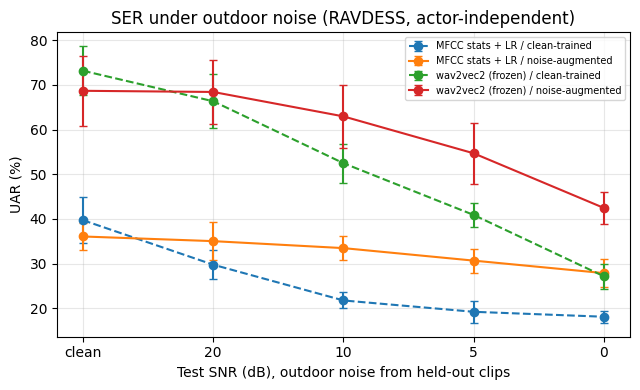

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for (f, t), d in summ.groupby(["features", "training"]):
    d = d.set_index("test_snr_db").loc[order]
    ax.errorbar(order, d["mean"] * 100, yerr=d["std"] * 100, marker="o", capsize=3,
                linestyle="-" if t == "noise-augmented" else "--", label=f"{f} / {t}")
ax.set_xlabel("Test SNR (dB), outdoor noise from held-out clips"); ax.set_ylabel("UAR (%)")
ax.set_title("SER under outdoor noise (RAVDESS, actor-independent)"); ax.legend(fontsize=7); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig("uar_vs_snr.png", dpi=200); plt.show()

In [ ]:
MAP4 = {"neutral": "neutral", "calm": "neutral",
        "happy": "positive", "surprised": "positive",
        "sad": "low-arousal negative",
        "angry": "high-arousal negative", "fearful": "high-arousal negative", "disgust": "high-arousal negative"}
y4 = meta.emo.map(MAP4).values
res4 = pd.concat([run(MF, "MFCC stats + LR", y4, groups), run(EM, "wav2vec2 (frozen)", y4, groups)])
s4 = res4.groupby(["features", "training", "test_snr_db"]).UAR.mean().mul(100).round(1).unstack()[order]
print(s4.to_string())
res4.to_csv("pilot_ser_4class.csv", index=False)

test_snr_db                        clean    20    10     5     0
features          training                                      
MFCC stats + LR   clean-trained     49.5  44.8  40.9  37.3  36.1
                  noise-augmented   44.7  45.1  41.5  42.5  40.8
wav2vec2 (frozen) clean-trained     74.0  70.1  60.6  47.1  35.2
                  noise-augmented   66.9  66.9  65.1  58.9  50.7


### How to write this up (Section 3 and the Section 15 reply)
- Report the clean-to-0 dB drop for the clean-trained model and the recovery from noise-augmented training, with the fold-level std.
- State plainly: acted corpus, 8 classes, public outdoor noise; it shows noise sensitivity and recovery, not the final outdoor-worker UAR.
- Weather conditioning (H1) and three-stream fusion (H2) cannot be tested with public data and are the grant's main experiments.

## Part B: wristband-only stress baseline on WESAD (non-verbal module)

Download WESAD from its official page (UCI / Siegen; search "WESAD dataset"), unzip, and put the folder in Google Drive. Each subject folder holds `S2/S2.pkl`, `S3/S3.pkl`, and so on. Check the licence terms on the page. Set `WESAD_DIR` below.
Task: baseline vs stress windows (60 s, 30 s step), wrist sensors only (BVP-derived HRV, EDA, skin temperature, motion), leave-one-subject-out.

In [ ]:
from google.colab import drive
drive.mount("/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ============================================================
# PART B: WESAD wristband-only stress baseline (one self-contained Colab cell)
# Copy ALL of this into ONE new code cell and run it.
# ============================================================
import os, glob, pickle, gc, warnings
import numpy as np, pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score
warnings.filterwarnings("ignore")

WESAD_DIR = "/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD"
WIN, STEP, FS_LABEL = 60, 30, 700      # window (s), step (s), label sampling rate (Hz)


def col(x):
    """Return a signal as a 1-D float array (handles shapes (N,) and (N,1))."""
    return np.asarray(x, dtype=float).reshape(len(x), -1)[:, 0]


def hrv_feats(bvp, fs=64):
    try:
        b, a = butter(3, [0.5, 8], btype="band", fs=fs)
        x = filtfilt(b, a, bvp)
        peaks, _ = find_peaks(x, distance=int(0.4 * fs))
        ibi = np.diff(peaks) / fs
        ibi = ibi[(ibi > 0.3) & (ibi < 2.0)]
        if len(ibi) < 5:
            return [np.nan] * 3
        return [ibi.mean(), ibi.std(), np.sqrt(np.mean(np.diff(ibi) ** 2))]
    except Exception:
        return [np.nan] * 3


def slope(x):
    return np.polyfit(np.arange(len(x)), x, 1)[0]


def window_feats(bvp, eda, tmp, acc, s, e):
    b = bvp[s * 64:e * 64]
    d = eda[s * 4:e * 4]
    t = tmp[s * 4:e * 4]
    a = np.linalg.norm(acc[s * 32:e * 32], axis=1)
    f = dict(zip(["ibi_mean", "sdnn", "rmssd"], hrv_feats(b)))
    f.update(eda_mean=d.mean(), eda_std=d.std(), eda_slope=slope(d), eda_max=d.max(),
             temp_mean=t.mean(), temp_std=t.std(), temp_slope=slope(t),
             acc_mean=a.mean(), acc_std=a.std())
    return f


# ---------- 1. Build windows from every subject ----------
subject_dirs = sorted(glob.glob(f"{WESAD_DIR}/S*"))
print("subject folders found:", len(subject_dirs))
rows = []
for sdir in subject_dirs:
    sid = os.path.basename(sdir)
    pkl = f"{sdir}/{sid}.pkl"
    if not os.path.exists(pkl):
        print(sid, "-> no .pkl, skipped")
        continue
    try:
        with open(pkl, "rb") as fh:
            d = pickle.load(fh, encoding="latin1")
        w = d["signal"]["wrist"]
        bvp, eda, tmp = col(w["BVP"]), col(w["EDA"]), col(w["TEMP"])
        acc = np.asarray(w["ACC"], dtype=float)
        lab = np.asarray(d["label"]).ravel()
        del d, w
        dur = int(min(len(lab) / FS_LABEL, len(bvp) / 64, len(eda) / 4, len(tmp) / 4, len(acc) / 32))
        n_before = len(rows)
        for s in range(0, dur - WIN + 1, STEP):
            l = lab[s * FS_LABEL:(s + WIN) * FS_LABEL]
            vals, cnt = np.unique(l, return_counts=True)
            top = vals[cnt.argmax()]
            if top not in (1, 2) or cnt.max() / len(l) < 0.8:   # 1 = baseline, 2 = stress
                continue
            f = window_feats(bvp, eda, tmp, acc, s, s + WIN)
            f.update(subject=sid, y=int(top == 2))
            rows.append(f)
        print(sid, "windows:", len(rows) - n_before)
    except Exception as ex:
        print(sid, "-> ERROR:", type(ex).__name__, ex)
    gc.collect()

W = pd.DataFrame(rows)
if W.empty:
    raise SystemExit("No windows were collected. Check WESAD_DIR and the messages above.")

# keep rows with valid non-HRV features; fill missing HRV values with the column median
hrv_cols = ["ibi_mean", "sdnn", "rmssd"]
print("windows with missing HRV:", int(W[hrv_cols].isna().any(axis=1).sum()), "of", len(W))
W = W.dropna(subset=[c for c in W.columns if c not in hrv_cols]).reset_index(drop=True)
W[hrv_cols] = W[hrv_cols].fillna(W[hrv_cols].median())
print("subjects:", W.subject.nunique(), "| windows:", len(W), "| stress share:", round(W.y.mean(), 2))

# ---------- 2. Leave-one-subject-out evaluation ----------
feat_cols = [c for c in W.columns if c not in ("subject", "y")]
SETS = {
    "EDA only": [c for c in feat_cols if c.startswith("eda")],
    "EDA + skin temp": [c for c in feat_cols if c.startswith(("eda", "temp"))],
    "All wrist (HRV+EDA+temp+motion)": feat_cols,
}
logo = LeaveOneGroupOut()
out = []
for name, cols in SETS.items():
    sc = []
    for tr, te in logo.split(W, W.y, W.subject):
        clf = RandomForestClassifier(300, class_weight="balanced", random_state=0, n_jobs=-1)
        clf.fit(W.loc[tr, cols], W.y[tr])
        sc.append(balanced_accuracy_score(W.y[te], clf.predict(W.loc[te, cols])))
    out.append((name, np.mean(sc) * 100, np.std(sc) * 100, len(sc)))
wesad = pd.DataFrame(out, columns=["feature set", "UAR mean (%)", "UAR std (%)", "subjects"]).round(1)
print()
print(wesad.to_string(index=False))
wesad.to_csv("pilot_wesad_results.csv", index=False)

subject folders found: 15
S10 windows: 60
S11 windows: 59
S13 windows: 59
S14 windows: 59
S15 windows: 60
S16 windows: 61
S17 windows: 61
S2 windows: 56
S3 windows: 57
S4 windows: 57
S5 windows: 59
S6 windows: 59
S7 windows: 59
S8 windows: 59
S9 windows: 58
windows with missing HRV: 0 of 883
subjects: 15 | windows: 883 | stress share: 0.35

                    feature set  UAR mean (%)  UAR std (%)  subjects
                       EDA only          72.4         15.2        15
                EDA + skin temp          86.1         13.8        15
All wrist (HRV+EDA+temp+motion)          88.1         14.5        15


### Notes for the proposal
- WESAD is a lab stress protocol, not outdoor work: describe this as a feasibility baseline for the wristband-only module, and say field data from speech-impaired workers is the main-study task.
- Download `pilot_ser_results.csv`, `uar_vs_snr.png`, and `pilot_wesad_results.csv` from the Colab file panel for the write-up.